```
06_edge_signal_engineering.ipynb
│
├── 0. Introduction
│   ├── Why edge signal engineering matters
│   ├── Sensor-to-inference pipeline
│   ├── Embedded vision constraints
│   └── Motivation for intelligent transmission
│
├── 1. Imports & Configuration
│   ├── Libraries
│   ├── Paths
│   ├── Device configuration
│   └── Utility setup
│
├── 2. Load Sample Images
│   ├── Healthy image
│   ├── Diseased image
│   ├── Visualization
│   └── Metadata inspection
│
├── 3. RGB vs Grayscale Analysis
│   ├── RGB visualization
│   ├── Grayscale conversion
│   ├── Visual comparison
│   ├── Histogram comparison
│   └── Disease feature preservation
│
├── 4. Memory Footprint Analysis
│   ├── RGB memory cost
│   ├── Grayscale memory cost
│   ├── Compression ratio
│   ├── Channel reduction analysis
│   └── Edge deployment implications
│
├── 5. Resolution Reduction Experiments
│   ├── 224×224
│   ├── 128×128
│   ├── 96×96
│   ├── 64×64
│   ├── 32×32
│   ├── Visual degradation study
│   └── Lesion visibility analysis
│
├── 6. JPEG Compression Experiments
│   ├── JPEG quality scaling
│   ├── Compression artifacts
│   ├── Transmission size estimation
│   ├── Edge bandwidth discussion
│   └── Feature degradation analysis
│
├── 7. Bandwidth Cost Modeling
│   ├── Raw RGB transmission
│   ├── Grayscale transmission
│   ├── Compressed transmission
│   ├── FPS-based bandwidth estimation
│   └── ESP32 feasibility analysis
│
├── 8. Edge Transmission Intelligence
│   ├── Why sending everything is inefficient
│   ├── Event-driven transmission
│   ├── Selective sensing
│   ├── Hierarchical edge intelligence
│   └── Distributed sensing architecture
│
├── 9. Adaptive Sensor Strategies
│   ├── Dynamic FPS
│   ├── Conditional transmission
│   ├── Confidence-gated sensing
│   ├── Power-aware operation
│   └── Embedded scheduling logic
│
├── 10. TinyML Signal Constraints
│   ├── ESP32 limitations
│   ├── RAM constraints
│   ├── compute constraints
│   ├── INT8 relevance
│   └── Tiny inference feasibility
│
├── 11. Signal Engineering Insights
│   ├── What information matters most?
│   ├── Signal vs bandwidth tradeoff
│   ├── Edge deployment tradeoffs
│   ├── Sensor hierarchy insights
│   └── Real-world engineering lessons
│
├── 12. Final Conclusions
│   ├── Key findings
│   ├── Edge AI implications
│   ├── Distributed sensing conclusions
│   └── Transition to ESP32 filtering notebook
│
└── NEXT NOTEBOOK
    └── 07_esp32_intelligent_filtering.ipynb
    ```

# ============================================================
# 06_edge_signal_engineering.ipynb
# ============================================================

EDGE SIGNAL ENGINEERING
============================================================

Traditional computer vision systems often assume:

    - unlimited bandwidth
    - unlimited power
    - unlimited compute

Real edge systems do NOT have these luxuries.

------------------------------------------------------------
EDGE DEVICES MUST OPTIMIZE:

    - memory usage
    - transmission bandwidth
    - sensor power
    - compute cost
    - inference latency

------------------------------------------------------------
THIS NOTEBOOK INVESTIGATES:

"What visual information is ACTUALLY necessary
for reliable edge AI inference?"

------------------------------------------------------------
KEY QUESTIONS

    - Is RGB necessary?
    - Can grayscale preserve disease information?
    - How much resolution is sufficient?
    - How much compression is acceptable?
    - What information should be transmitted?

------------------------------------------------------------

    Computer Vision Research
                    ↓
    Edge-Aware Signal Engineering

In [1]:
# IMPORTS

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [8]:
DATASET_PATH = "../../data/raw/train"

We intentionally use:

    one healthy
    one diseased
because: signal comparison matters.

In [11]:
# SAMPLE IMAGE PATHS

healthy_path = os.path.join(DATASET_PATH,"Tomato___healthy")
disease_path = os.path.join(DATASET_PATH,"Tomato___Late_blight")

# LOAD SAMPLE FILES
healthy_file = os.listdir(healthy_path)[0]
disease_file = os.listdir(disease_path)[0]

healthy_img = cv2.imread(os.path.join(healthy_path, healthy_file))
disease_img = cv2.imread(os.path.join(disease_path, disease_file))

healthy_img = cv2.cvtColor(healthy_img,cv2.COLOR_BGR2RGB)
disease_img = cv2.cvtColor(disease_img,cv2.COLOR_BGR2RGB)

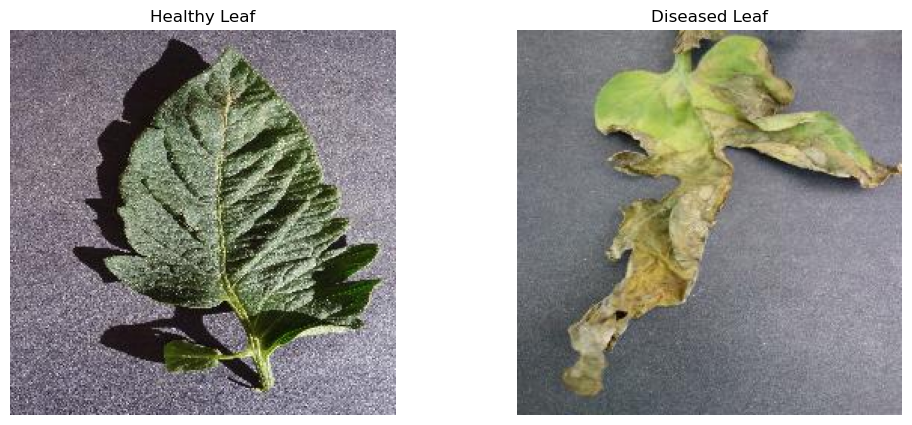

In [12]:
# VISUALIZE SAMPLE IMAGES

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(healthy_img)
plt.title("Healthy Leaf")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(disease_img)
plt.title("Diseased Leaf")
plt.axis("off")

plt.show()

OBSERVATIONS
------------------------------------------------------------

Healthy leaves:
- visually smoother
- more uniform green distribution
- fewer lesion structures

Diseased leaves:
- texture irregularities
- dark lesion regions
- spatial discoloration
- edge discontinuities

------------------------------------------------------------
IMPORTANT QUESTION

Do we need FULL RGB information
to preserve these disease patterns?

This motivates grayscale analysis.

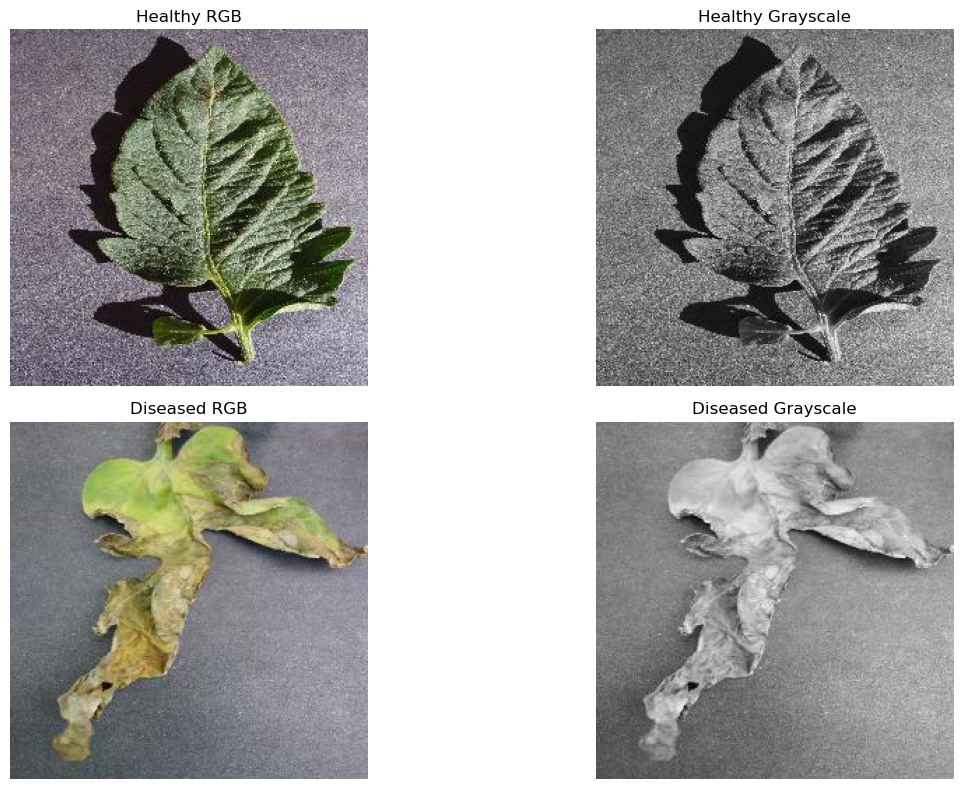

In [14]:
# RGB → GRAYSCALE CONVERSION

healthy_gray = cv2.cvtColor(healthy_img,cv2.COLOR_RGB2GRAY)
disease_gray = cv2.cvtColor(disease_img,cv2.COLOR_RGB2GRAY)

# RGB VS GRAYSCALE
plt.figure(figsize=(14,8))

# HEALTHY RGB
plt.subplot(2,2,1)
plt.imshow(healthy_img)
plt.title("Healthy RGB")
plt.axis("off")

# HEALTHY GRAYSCALE
plt.subplot(2,2,2)
plt.imshow(healthy_gray,cmap='gray')
plt.title("Healthy Grayscale")
plt.axis("off")

# DISEASED RGB
plt.subplot(2,2,3)
plt.imshow(disease_img)
plt.title("Diseased RGB")
plt.axis("off")

# DISEASED GRAYSCALE
plt.subplot(2,2,4)
plt.imshow(disease_gray,cmap='gray')
plt.title("Diseased Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

# ANALYSIS

KEY INSIGHT
------------------------------------------------------------

Even after grayscale conversion:

    - lesion boundaries remain visible
    - texture discontinuities persist
    - infected regions remain distinguishable

------------------------------------------------------------
THIS IS EXTREMELY IMPORTANT FOR EDGE AI

Why?

    RGB images require:
    3 channels

    Grayscale requires:
    1 channel

------------------------------------------------------------
Potential benefits:

    - lower memory usage
    - lower transmission bandwidth
    - lower storage requirements
    - faster processing

------------------------------------------------------------
This demonstrates:

    disease information is partially preserved
    even under aggressive signal simplification.

# SECTION 4 — MEMORY FOOTPRINT ANALYSIS

This section answers:

    “How expensive is image information?”

EACH IMAGE holds 2 significant factor within it

    1. abstract vision data.
    2. what is its measurable transmission cost?

In [15]:
# IMAGE SHAPES
print("Healthy RGB Shape :", healthy_img.shape)
print("Healthy Gray Shape:", healthy_gray.shape)
print()
print("Disease RGB Shape :", disease_img.shape)
print("Disease Gray Shape:", disease_gray.shape)

Healthy RGB Shape : (256, 256, 3)
Healthy Gray Shape: (256, 256)

Disease RGB Shape : (256, 256, 3)
Disease Gray Shape: (256, 256)


In [ ]:
# MEMORY FOOTPRINT CALCULATION
rgb_memory_bytes = healthy_img.nbytes
gray_memory_bytes = healthy_gray.nbytes

print(f"RGB Memory       : {rgb_memory_bytes} bytes")
print(f"Grayscale Memory : {gray_memory_bytes} bytes")

RGB Memory       : 196608 bytes
Grayscale Memory : 65536 bytes


In [ ]:
# MEMORY IN KB
rgb_kb = rgb_memory_bytes / 1024
gray_kb = gray_memory_bytes / 1024

print(f"RGB Size       : {rgb_kb:.2f} KB")
print(f"Grayscale Size : {gray_kb:.2f} KB")

RGB Size       : 192.00 KB
Grayscale Size : 64.00 KB


In [18]:
# MEMORY SAVINGS
reduction = ((rgb_memory_bytes - gray_memory_bytes)/ rgb_memory_bytes) * 100
print(f"Memory Reduction: {reduction:.2f}%")

Memory Reduction: 66.67%


##### RGB -> 3 channels

##### Grayscale -> 1 channel

Immediately:
### memory reduces by <span style="font-size:18pt; color:pink">~66%.

That is HUGE for:

    wireless transmission
    edge storage

signal simplification directly reduces:

    bandwidth
    RAM
    storage
    transmission energy

WITHOUT requiring:

    neural networks
    quantization
    inference tricks

while deployment, simple signal engineering matters more 

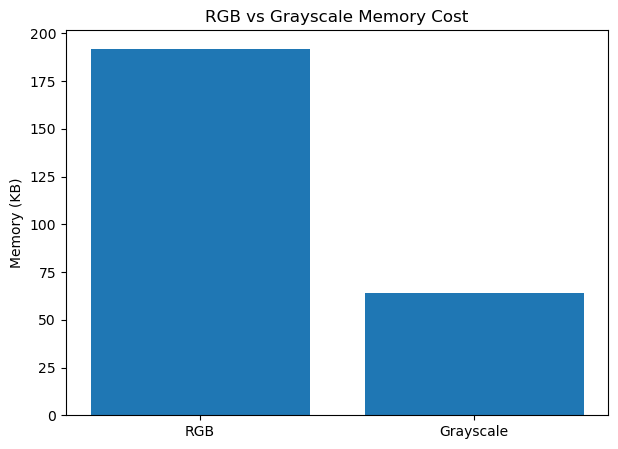

In [19]:
# MEMORY COMPARISON VISUALIZATION

labels = ["RGB","Grayscale"]
sizes = [rgb_kb,gray_kb]

plt.figure(figsize=(7,5))
plt.bar(labels, sizes)
plt.ylabel("Memory (KB)")
plt.title("RGB vs Grayscale Memory Cost")

plt.show()

# CHANNEL ANALYSIS

RGB stores:

    - Red channel
    - Green channel
    - Blue channel

------------------------------------------------------------
Each additional channel increases:

    - memory usage
    - bandwidth cost
    - transmission latency

------------------------------------------------------------
QUESTION

    Do all channels contribute equally to disease recognition?

If not:

    partial channel reduction may be feasible for edge systems.

core question to be asked: <span style="color:orange;font-size:20pt">Which information is worth transmitting?</span>

# EDGE DEPLOYMENT IMPLICATIONS

EDGE IMPLICATIONS

Reducing image complexity can improve:

    - transmission speed
    - battery efficiency
    - RAM utilization
    - edge responsiveness


FOR ESP32-CAM

Grayscale transmission may:

    - reduce WiFi payload size
    - reduce buffering pressure
    - reduce memory fragmentation
    - improve real-time responsiveness

------------------------------------------------------------
THIS IS CRITICAL FOR:

    - embedded AI
    - robotics
    - drones
    - remote sensing

So next step would be to investigate: <span style="color:pink;font-size:20pt">“How much spatial detail is ACTUALLY necessary?”</span>

Because, resolution dominates:

    memory
    compute
    bandwidth

In [20]:
# SECTION 5 — RESOLUTION REDUCTION EXPERIMENTS

# RESOLUTION EXPERIMENTS
sizes = [
    224,
    128,
    96,
    64,
    32
]

resized_images = []

for size in sizes:
    resized = cv2.resize(disease_img,(size, size))
    resized_images.append(resized)

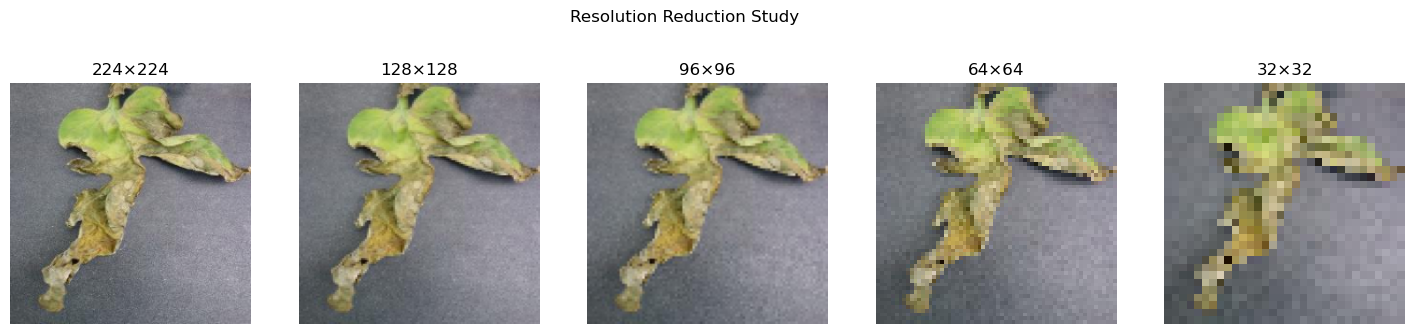

In [21]:
# VISUALIZE RESOLUTION REDUCTION

plt.figure(figsize=(18,4))
for i, img in enumerate(resized_images):
    plt.subplot(1, len(sizes), i+1)
    plt.imshow(img)
    plt.title(f"{sizes[i]}×{sizes[i]}")
    plt.axis("off")

plt.suptitle("Resolution Reduction Study")
plt.show()

| Resolution | Observation                 |
| ---------- | --------------------------- |
| 224        | clear lesions               |
| 128        | mostly preserved            |
| 96         | acceptable                  |
| 64         | lesion details degrade      |
| 32         | severe information collapse |


In [22]:
# PIXEL COUNT ANALYSIS

for size in sizes:
    pixels = size * size
    print(f"{size}×{size} "f"→ {pixels:,} pixels")

224×224 → 50,176 pixels
128×128 → 16,384 pixels
96×96 → 9,216 pixels
64×64 → 4,096 pixels
32×32 → 1,024 pixels


In [23]:
# MEMORY SCALING
memory_costs = []
for img in resized_images:
    memory_costs.append(img.nbytes / 1024)

for size, mem in zip(sizes, memory_costs):
    print(f"{size}×{size} "f"→ {mem:.2f} KB")

224×224 → 147.00 KB
128×128 → 48.00 KB
96×96 → 27.00 KB
64×64 → 12.00 KB
32×32 → 3.00 KB


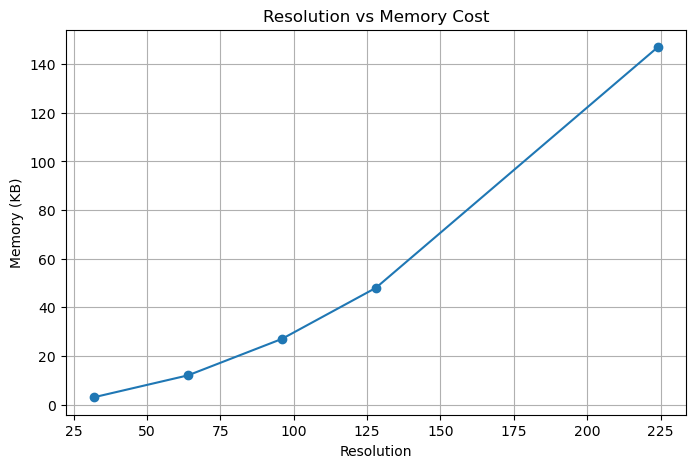

In [24]:
# MEMORY VS RESOLUTION

plt.figure(figsize=(8,5))
plt.plot(sizes,memory_costs,marker='o')

plt.xlabel("Resolution")
plt.ylabel("Memory (KB)")
plt.title("Resolution vs Memory Cost")
plt.grid(True)
plt.show()

Resolution reduction gives: quadratic savings

224² = 50,176 pixels

64² = 4,096 pixels -> enormous reduction

# LESION VISIBILITY ANALYSIS

### OBSERVATIONS
As resolution decreases:

    - fine lesion texture disappears
    - edge sharpness degrades
    - small infection regions collapse

------------------------------------------------------------
However:

    moderate reductions (128–96)
    still preserve substantial disease structure.

------------------------------------------------------------
BUT. Excessive reduction destroys pathology.

# SECTION 6 — JPEG COMPRESSION EXPERIMENTS

Let's study: <span style="color:yellow;font-size:20pt">compression artifacts</span>.

This is critical because:
ESP32-CAM already uses JPEG internally

In [26]:
# JPEG COMPRESSION LEVELS
qualities = [100,80,60,40,20]

compressed_images = []
compressed_sizes = []

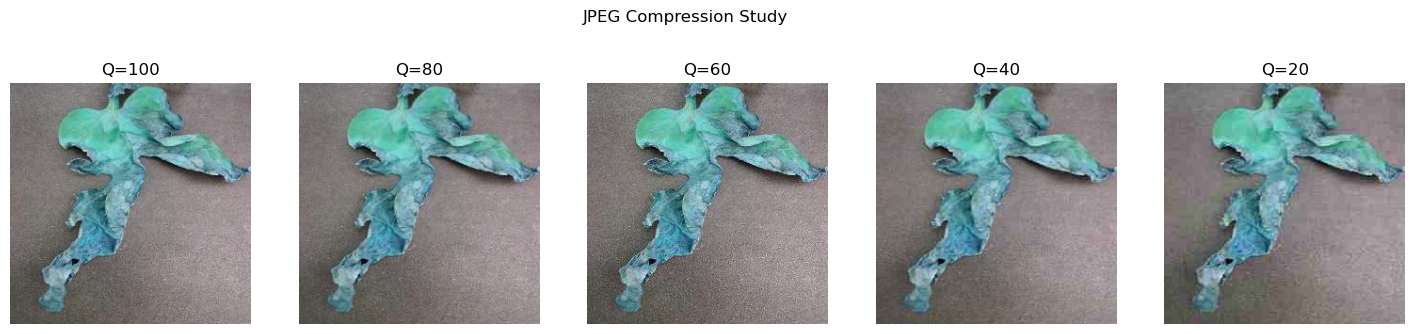

In [ ]:
# APPLY JPEG COMPRESSION
for q in qualities:
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY),q]

    success, encoded_img = cv2.imencode('.jpg',disease_img,encode_param)
    compressed_sizes.append(len(encoded_img) / 1024)

    decoded = cv2.imdecode(encoded_img,cv2.IMREAD_COLOR)
    decoded = cv2.cvtColor(decoded,cv2.COLOR_BGR2RGB)

    compressed_images.append(decoded)

# VISUALIZE COMPRESSION ARTIFACTS
plt.figure(figsize=(18,4))
for i, img in enumerate(compressed_images):
    plt.subplot(1, len(qualities), i+1)
    plt.imshow(img)
    plt.title(f"Q={qualities[i]}")
    plt.axis("off")

plt.suptitle("JPEG Compression Study")
plt.show()

In [28]:
# FILE SIZE ANALYSIS

for q, size in zip(qualities,compressed_sizes):
    print(f"Quality {q} "f"→ {size:.2f} KB")

Quality 100 → 37.13 KB
Quality 80 → 13.51 KB
Quality 60 → 11.88 KB
Quality 40 → 6.04 KB
Quality 20 → 3.88 KB


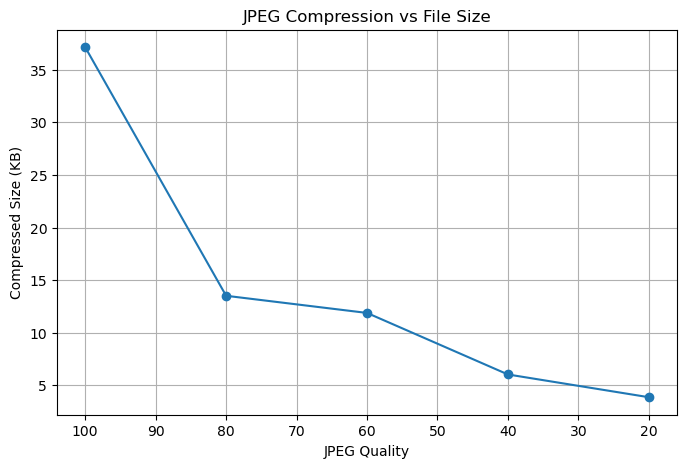

In [29]:
# JPEG SIZE VISUALIZATION
plt.figure(figsize=(8,5))
plt.plot(qualities,compressed_sizes,marker='o')

plt.gca().invert_xaxis()
plt.xlabel("JPEG Quality")
plt.ylabel("Compressed Size (KB)")
plt.title("JPEG Compression vs File Size")
plt.grid(True)

plt.show()

Lower JPEG quality:

    massively reduces bandwidth
    but introduces artifacts

Key Question to ask:  <span style="font-size:20pt;color:orange">When do artifacts destroy disease information?


# COMPRESSION ANALYSIS

KEY OBSERVATIONS

Moderate JPEG compression:

        - preserves major lesion structures
        - significantly reduces file size

Extreme compression:

        - destroys texture fidelity
        - introduces block artifacts
        - obscures disease boundaries

------------------------------------------------------------
THIS IS A CRITICAL EDGE TRADEOFF

        Lower bandwidth
                vs
        Signal preservation

In [30]:
# SECTION 7 — BANDWIDTH COST MODELING

# Suppose ESP32-CAM transmits: ~10 frames per second
# Question: How much bandwidth is required?

# BANDWIDTH ESTIMATION
fps = 10
print("Bandwidth Estimates:\n")

for q, size in zip(qualities,compressed_sizes):
    bandwidth_per_sec = size * fps
    print(
        f"JPEG Q={q} "
        f"→ {bandwidth_per_sec:.2f} KB/sec"
    )

Bandwidth Estimates:

JPEG Q=100 → 371.32 KB/sec
JPEG Q=80 → 135.14 KB/sec
JPEG Q=60 → 118.84 KB/sec
JPEG Q=40 → 60.37 KB/sec
JPEG Q=20 → 38.75 KB/sec


In [ ]:
# RAW VS COMPRESSED

raw_size = disease_img.nbytes / 1024
compressed_size = compressed_sizes[2]

print(f"Raw RGB Size       : {raw_size:.2f} KB")
print(f"Compressed JPEG    : {compressed_size:.2f} KB")

reduction = ((raw_size - compressed_size)/ raw_size) * 100
print(f"Bandwidth Reduction: "f"{reduction:.2f}%")

Raw RGB Size       : 192.00 KB
Compressed JPEG    : 11.88 KB
Bandwidth Reduction: 93.81%


Compression can reduce: 
### transmission burden dramatically.

WiFi transmission itself costs:

    power
    latency
    buffering
    packet retries

# ESP32 FEASIBILITY

ESP32-CAM CONSIDERATIONS

ESP32 has:

    - limited RAM
    - limited buffering
    - limited compute

------------------------------------------------------------
Reducing:

    - resolution
    - color channels
    - JPEG quality

can dramatically improve:

    - responsiveness
    - transmission reliability
    - memory stability

------------------------------------------------------------
THIS IS WHY:

    signal engineering matters before AI inference.

# FINAL INSIGHTS

1. Grayscale significantly reduces memory cost.
2. Resolution reduction provides quadratic savings.
3. JPEG compression dramatically lowers bandwidth.
4. Moderate compression preserves useful pathology.
5. Edge AI requires balancing:

        - signal fidelity
        - bandwidth
        - latency
        - memory constraints

This notebook demonstrates:

    computer vision is fundamentally tied to:
#### communication systems engineering.

# SECTION 8 — EDGE TRANSMISSION INTELLIGENCE

Traditional sensing systems often transmit: EVERY frame.
This is extremely inefficient.

------------------------------------------------------------
PROBLEMS

    - wasted bandwidth
    - wasted power
    - increased latency
    - unnecessary processing

------------------------------------------------------------
MODERN EDGE SYSTEMS USE:

    - selective transmission
    - event-driven sensing
    - adaptive scheduling
    - hierarchical intelligence

------------------------------------------------------------
CORE IDEA

    Transmit only:
    IMPORTANT information.

---

## WHY SENDING EVERYTHING IS BAD

Imagine:

#### ESP32 streams: 10 FPS continuously.

QUESTION
What if:

    - nothing changes?
    - no anomaly exists?
    - no disease region is visible?

------------------------------------------------------------
Then:

    most transmitted frames contain:
    redundant information.

------------------------------------------------------------
THIS CAUSES

    - network congestion
    - battery drain
    - edge latency
    - inference waste

Most intelligent systems optimize -> information flow 

NOT:

    raw compute power

foundational in:

    aerospace
    robotics
    swarm sensing
    surveillance systems

# EVENT-DRIVEN TRANSMISSION

Instead of:
continuous transmission

Use:
conditional transmission.

EXAMPLE

No motion:

    → no transmission

Motion detected:

    → transmit image

This dramatically reduces:

    - bandwidth
    - latency
    - energy usage

# HIERARCHICAL EDGE AI

    ESP32-CAM
        ↓
    cheap lightweight filtering
        ↓
    MacBook MPS
        ↓
    heavy AI reasoning

EDGE NODE RESPONSIBILITIES

    ESP32:
    - motion detection
    - grayscale conversion
    - ROI extraction
    - compression
    - adaptive FPS

CENTRAL NODE RESPONSIBILITIES

    MacBook:
    - MobileNet inference
    - Grad-CAM
    - confidence scoring
    - visualization
    - telemetry

A distributed intelligence architecture.

# MULTI-LEVEL TRANSMISSION

EXAMPLE TRANSMISSION LEVELS:

    LEVEL 0
    No activity
    → no transmission


    LEVEL 1
    Motion detected
    → low-resolution transmission


    LEVEL 2
    Possible anomaly
    → ROI transmission


    LEVEL 3
    High confidence target
    → full transmission + inference

This is common in:

    - aerospace sensing
    - robotics
    - autonomous systems

In [33]:
# SELECTIVE TRANSMISSION ANALYSIS
frames_per_sec = 10
active_percentages = [
    1,
    5,
    10,
    25,
    50
]
print("Selective Transmission Analysis\n")

for active in active_percentages:
    effective_fps = (
        frames_per_sec
        * (active / 100)
    )
    print(
        f"Activity Level: {active}% "
        f"→ Effective FPS: {effective_fps:.2f}"
    )

Selective Transmission Analysis

Activity Level: 1% → Effective FPS: 0.10
Activity Level: 5% → Effective FPS: 0.50
Activity Level: 10% → Effective FPS: 1.00
Activity Level: 25% → Effective FPS: 2.50
Activity Level: 50% → Effective FPS: 5.00


THAT MEANS, If:

    only 5% of frames matter,

then:

    95% transmission savings becomes possible.

# SECTION 8.7 — EDGE TRANSMISSION CONCLUSIONS

KEY TAKEAWAYS
1. Continuous streaming is inefficient.

2. Most frames often contain redundant information.

3. Event-driven transmission dramatically reduces:

    - bandwidth
    - power usage
    - latency

4. Hierarchical intelligence enables:

    - scalable sensing
    - efficient compute allocation
    - embedded optimization

EDGE AI is not only **model inference**. It is **intelligent information management**.

This section explores: **dynamic sensing behavior**.

Real embedded systems rarely operate at: fixed behavior forever

#### They adapt continuously

# SECTION 9 — ADAPTIVE SENSOR STRATEGIES

Real edge systems dynamically adapt:

    - frame rate
    - compression quality
    - transmission frequency
    - sensing behavior

based on:

    - activity
    - power
    - confidence
    - environmental conditions

THIS IMPROVES

    - efficiency
    - responsiveness
    - battery life
    - scalability

### DYNAMIC FPS EXAMPLE

EXAMPLE

Idle State → 1 FPS

Motion State → 10 FPS

High Activity → 15 FPS

This reduces:

    - power consumption
    - redundant sensing
    - transmission cost

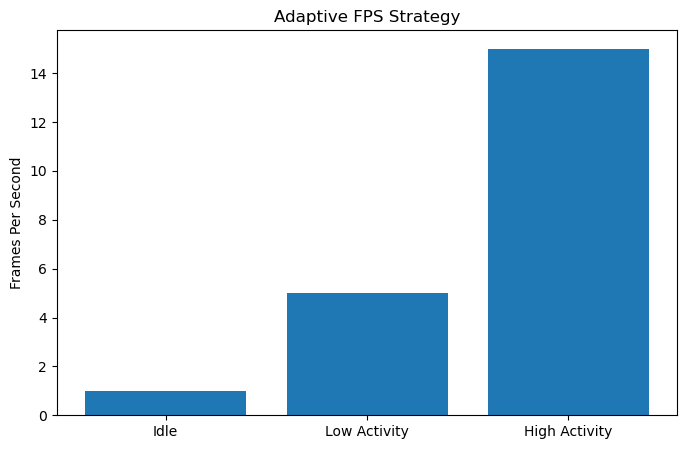

In [34]:
# ADAPTIVE FPS SIMULATION

states = ["Idle","Low Activity","High Activity"]
fps_values = [1,5,15]

plt.figure(figsize=(8,5))
plt.bar(states,fps_values)
plt.ylabel("Frames Per Second")
plt.title("Adaptive FPS Strategy")
plt.show()

### CONDITIONAL TRANSMISSION

#### LOGIC

    IF:
    motion_detected == TRUE

    AND:
    confidence > threshold

    THEN:
    transmit frame

    ELSE:
    discard frame
This is confidence-gated sensing.

### POWER-AWARE OPERATION

Battery-powered devices must optimize:

        - sensing frequency
        - transmission frequency
        - compute usage

WHY?

    Wireless transmission itself consumes significant power.

Thus:

    avoiding unnecessary transmission can significantly extend system lifetime.

### EMBEDDED SCHEDULING

SCHEDULING EXAMPLE

    Normal State:
        → low sensing rate

    Potential anomaly:
        → increase sensing

    High-confidence target:
        → burst transmission

This creates: adaptive edge responsiveness.

# FINAL INSIGHTS

1. Edge systems benefit from adaptive sensing.

2. Dynamic FPS reduces:
    - power usage
    - bandwidth
    - redundant compute

3. Confidence-gated transmission improves:
    - efficiency
    - scalability

4. Adaptive scheduling enables:
    intelligent resource management.

This mirrors IN real-world robotics and aerospace architectures.

# SECTION 10 — TINYML SIGNAL CONSTRAINTS

Now let's discuss <span style="color:pink">what ESP32 can ACTUALLY handle.</span>

Because: embedded AI is constrained by <span style='color:pink'>physics</span>

### TINYML CONSTRAINTS

TinyML refers to: machine learning on microcontrollers.

TARGET HARDWARE

    - ESP32
    - STM32
    - Arduino-class devices

These systems are: extremely resource constrained.

THUS, signal engineering becomes critical.

### ESP32 LIMITATIONS

ESP32 has limitations in:

    - RAM
    - compute
    - storage
    - floating-point performance

THIS MEANS:

    Large CNNs are generally impractical.

Thus:

    ESP32 should perform: cheap intelligence only.

### INFEASIBLE TASKS

ESP32 struggles with:

    - large CNNs
    - segmentation networks
    - transformers
    - large-resolution inference
    - heavy feature extraction

WHY? Because: memory and compute budgets are tiny.

### FEASIBLE TASKS

##### GOOD ESP32 TASKS

ESP32 performs well for:

    - motion detection
    - grayscale conversion
    - binary masks
    - ROI extraction
    - event triggering
    - adaptive scheduling

These operations are cheap and efficient.

### INT8 DISCUSSION
INT8 quantization is critical for TinyML.

------------------------------------------------------------
WHY?

Integer arithmetic:

    - reduces memory
    - reduces compute cost
    - improves embedded feasibility

------------------------------------------------------------
Thus:

    TinyML systems heavily rely on:
    INT8 inference.

### TINY INFERENCE FEASIBILITY

Feasible:

    - binary classification
    - event detection
    - anomaly detection
    - tiny CNNs

Not realistic:

    - large MobileNet inference
    - full Grad-CAM
    - segmentation systems

Thus hierarchical AI architecture is preferred.

### FINAL TINYML INSIGHTS

1. ESP32 is best used as:
   intelligent sensing node.

2. Lightweight filtering is often more valuable
   than heavy inference.

3. TinyML requires:
    - aggressive optimization
    - tiny models
    - INT8 arithmetic

4. Distributed intelligence architectures are
   more scalable than forcing all AI onto edge devices.

# SECTION 11 — SIGNAL ENGINEERING INSIGHTS

    computer vision
    embedded systems
    communication constraints
    edge intelligence

#### WHAT INFORMATION MATTERS MOST?
### SIGNAL PRIORITIZATION

Not all visual information is equally valuable.

    Critical disease features include:
    - lesion boundaries
    - texture irregularities
    - discoloration regions

    Less critical information may include:
    - background details
    - high-frequency noise
    - redundant frames

Thus:
signal prioritization becomes possible.

# SIGNAL VS BANDWIDTH

### EDGE AI TRADEOFF

Higher signal fidelity:

    → better detail
    → higher bandwidth cost

Lower signal fidelity:

    → reduced transmission
    → possible information loss

GOOD EDGE ENGINEERING FINDS the optimal balance.

### MODERN EDGE SYSTEMS

The strongest AI systems use hierarchical intelligence.

    EDGE NODE:
    cheap filtering

    CENTRAL NODE:
    deep reasoning

This enables:

    - scalability
    - efficiency
    - lower latency
    - intelligent compute allocation

### REAL-WORLD LESSONS
This notebook demonstrated:

    - computer vision is tied to communication systems
    - edge AI requires signal optimization
    - bandwidth matters
    - transmission cost matters
    - embedded constraints matter

------------------------------------------------------------
Thus successful edge AI systems require joint optimization of:

    - sensing
    - transmission
    - inference
    - hardware

# ============================================================
# FINAL CONCLUSIONS
# ============================================================

This notebook transformed computer vision analysis into edge-aware signal engineering.

KEY INSIGHTS

1. Intelligent signal reduction dramatically improves:

    - efficiency
    - scalability
    - responsiveness

2. ESP32 is best used for:

    - lightweight filtering
    - event detection
    - intelligent transmission

3. Heavy AI inference should remain on:

    - laptops
    - edge servers
    - Raspberry Pi-class systems

4. Distributed intelligence architectures are highly effective for embedded AI systems.

------------------------------------------------------------
NEXT NOTEBOOK

```07_esp32_intelligent_filtering.ipynb```

Focus: camera-side intelligence implementation.